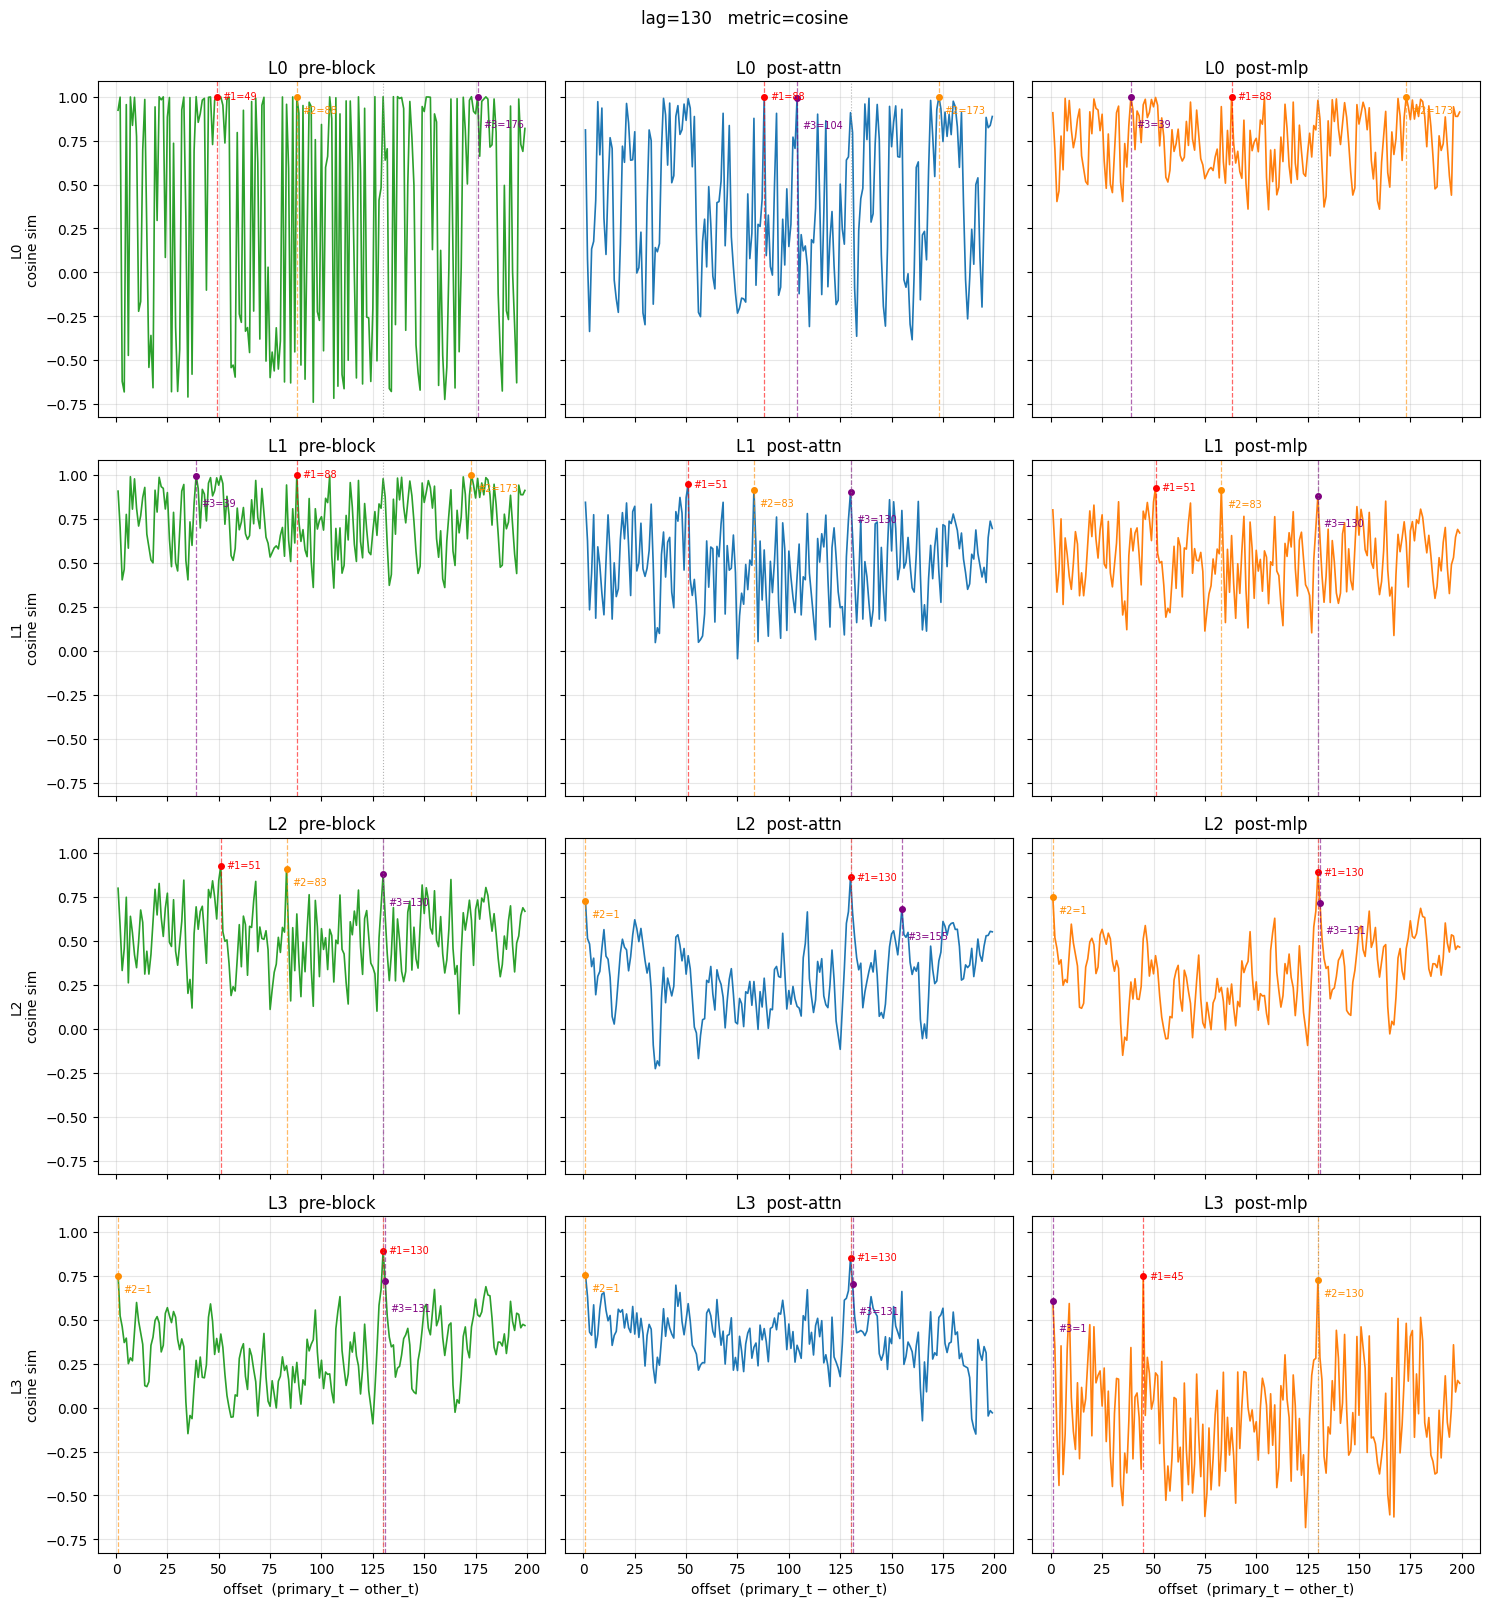

In [101]:
model_used = model
LAG = 130
primary_t = 199
t_lower   = 0
METRIC = "cosine"          # "cosine" or "dot"
N_TOP = 3
top_colors = ["red", "darkorange", "purple"]

def sim(a, b, metric):
    if metric == "cosine":
        return F.cosine_similarity(a, b, dim=0).item()
    elif metric == "dot":
        return torch.dot(a, b).item()
    raise ValueError(metric)

def similarity_by_offset(resid, primary_t, t_lower=0, metric="cosine"):
    primary_vec = resid[0, primary_t, :]
    sims = {}

    for other_t in range(primary_t - 1, t_lower - 1, -1):
        dist_t = primary_t - other_t
        sims[dist_t] = sim(primary_vec, resid[0, other_t, :], metric)

    return sims

def plot_similarity_panel(ax, sims_dict, color, lag, n_top, top_colors):
    dists_t = np.array(list(sims_dict.keys()))
    sims = np.array(list(sims_dict.values()))

    ax.plot(dists_t, sims, lw=1.2, color=color)

    order = np.argsort(sims)[::-1][:n_top]
    for rank, i in enumerate(order):
        c = top_colors[rank]
        ax.axvline(dists_t[i], color=c, ls="--", lw=0.9, alpha=0.6)
        ax.plot(dists_t[i], sims[i], "o", color=c, ms=4)
        ax.annotate(f"#{rank+1}={dists_t[i]}", (dists_t[i], sims[i]),
                    textcoords="offset points", xytext=(4, -2 - 10*rank),
                    fontsize=7, color=c)

    if lag <= dists_t[-1]:
        ax.axvline(lag, color="grey", ls=":", lw=0.8, alpha=0.6)

ylabel = {"cosine": "cosine sim", "dot": "dot product"}[METRIC]

seq = generate_autocorr(T=200, rho=0.9, lag=LAG, seed=None)
x = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
    pred, attns, resids_post_attn, resids_post_mlp = model_used(x)
    embedding = model_used.W_r(x.unsqueeze(-1))

n_layers = model_used.n_layers

fig, axes = plt.subplots(n_layers, 3, figsize=(15, 4 * n_layers),
                         sharex=True, sharey=True, squeeze=False)

for li in range(n_layers):
    resid_pre = embedding if li == 0 else resids_post_mlp[li - 1]

    snapshots = [
        ("pre-block", resid_pre,            "tab:green"),
        ("post-attn", resids_post_attn[li], "tab:blue"),
        ("post-mlp",  resids_post_mlp[li],  "tab:orange"),
    ]

    for col, (name, resid, color) in enumerate(snapshots):
        ax = axes[li, col]

        sims_dict = similarity_by_offset(resid, primary_t, t_lower, metric=METRIC)
        plot_similarity_panel(ax, sims_dict, color, LAG, N_TOP, top_colors)

        ax.set_title(f"L{li}  {name}")
        ax.grid(alpha=0.3)

for ax in axes[-1, :]:
    ax.set_xlabel("offset  (primary_t − other_t)")

for li in range(n_layers):
    axes[li, 0].set_ylabel(f"L{li}\n{ylabel}")

fig.suptitle(f"lag={LAG}   metric={METRIC}", y=1.001)
fig.tight_layout()
plt.show()

#### Question: can we make a metric that does the following
1) Runs many of these experiments, starting at one point in the network and ending at another point in the model
2) Record the starting top 2 vecs, and the ending top 2 vecs for each experiment. 
3) Considering **only experiments where the top vec does NOT correspond to the correct lag:**
    - What percentage of those experiments do end with the top vec corresponding to the correct lag?

- First, simplifying things by making a modified_forward method that allows you to customize the forward past (via patching or ablation)

In [ ]:
def modified_forward(model_used, x,skip_attn=None,skip_mlp=None,patch_attn=None,return_all=False):

    skip_attn  = skip_attn  or set()
    skip_mlp   = skip_mlp   or set()
    patch_attn = patch_attn or {}

    model_used.eval()

    if x.ndim == 1:
        x = x.unsqueeze(0)

    B, T = x.shape

    pos = torch.arange(T, device=x.device).unsqueeze(0).expand(B, T)

    idx = torch.arange(T, device=x.device)
    mask = idx.unsqueeze(0) > idx.unsqueeze(1)

    attns = []
    resids_post_attn = []
    resids_post_mlp = []

    with torch.no_grad():
        resid = model_used.W_r(x.unsqueeze(-1))

        for li, heads in enumerate(model_used.layers):

            delta = 0

            if li in skip_attn:
                for head_params in heads:
                    A = torch.zeros(B, T, T, device=x.device, dtype=resid.dtype)
                    attns.append(A)

            elif li in patch_attn:
                A_patch = patch_attn[li].to(x.device)

                for head_params in heads:
                    WQ, WK, WV, WO = head_params

                    A = A_patch
                    d = (A @ (resid @ WV)) @ WO

                    delta = delta + d
                    attns.append(A)

            else:
                for head_params in heads:
                    A, d = model_used._head(resid, head_params, pos, mask)
                    delta = delta + d
                    attns.append(A)

            resid = resid + delta
            resids_post_attn.append(resid.clone())

            if model_used.use_mlp and li not in skip_mlp:
                resid = resid + model_used.mlps[li](resid)

            resids_post_mlp.append(resid.clone())

        pred = model_used.W_U(resid).squeeze(-1)

    if return_all:
        return pred, attns, resids_post_attn, resids_post_mlp

    return pred

In [112]:
LAGS_TO_TEST = [1, 5, 10, 20, 30, 40, 50, 60, 80, 110, 150]
LAYERS       = list(range(model.n_layers))
N_SEQS       = 200
TOL          = 1
T, rho       = 200, 0.9
primary_t    = 199

from tqdm import tqdm

results = {}

for LAG in tqdm(LAGS_TO_TEST, desc="lags"):
    xL, _, _ = make_dataset_lagset(N_SEQS, T, rho, [LAG], seed=LAG)
    xL = xL.to(device)

    with torch.no_grad():
        _, _, resids_post_attn, resids_post_mlp = model(xL)
        embedding = model.W_r(xL.unsqueeze(-1))

    for li in LAYERS:
        resid_pre = embedding if li == 0 else resids_post_mlp[li - 1]

        correct = 0
        for s in range(N_SEQS):
            vec        = resid_pre[s, primary_t, :]
            others     = resid_pre[s, :primary_t, :]
            sims       = F.cosine_similarity(vec.unsqueeze(0), others, dim=1)
            top_offset = int(primary_t - sims.argmax().item())
            if abs(top_offset - LAG) <= TOL:
                correct += 1

        results[(LAG, li)] = correct / N_SEQS

# ---- table ----
col_w = 12
header = f"{'lag':>6} |"
for li in LAYERS:
    header += f"  {'L'+str(li+1)+' pre-attn':>{col_w}}"
print(header)
print("-" * len(header))

for LAG in LAGS_TO_TEST:
    row = f"{LAG:>6} |"
    for li in LAYERS:
        pct = results[(LAG, li)] * 100
        row += f"  {pct:>{col_w}.0f}%"
    print(row)

print()
print(f"N={N_SEQS} seqs per lag, tol=±{TOL}, primary_t={primary_t}")
print("% = fraction of sequences where top cosine-sim offset == true lag (±tol)")

lags: 100%|██████████| 11/11 [00:05<00:00,  1.98it/s]

   lag |   L1 pre-attn   L2 pre-attn   L3 pre-attn   L4 pre-attn
----------------------------------------------------------------
     1 |             4%             4%            25%            74%
     5 |             2%            13%            43%            82%
    10 |             6%            10%            48%            86%
    20 |             4%            11%            44%            78%
    30 |             2%             8%            55%            90%
    40 |             3%             8%            44%            84%
    50 |             2%            10%            44%            86%
    60 |             4%             7%            54%            88%
    80 |             4%             9%            54%            96%
   110 |             4%            14%            55%            98%
   150 |             2%            10%            60%            97%

N=200 seqs per lag, tol=±1, primary_t=199
% = fraction of sequences where top cosine-sim offset == true lag (±

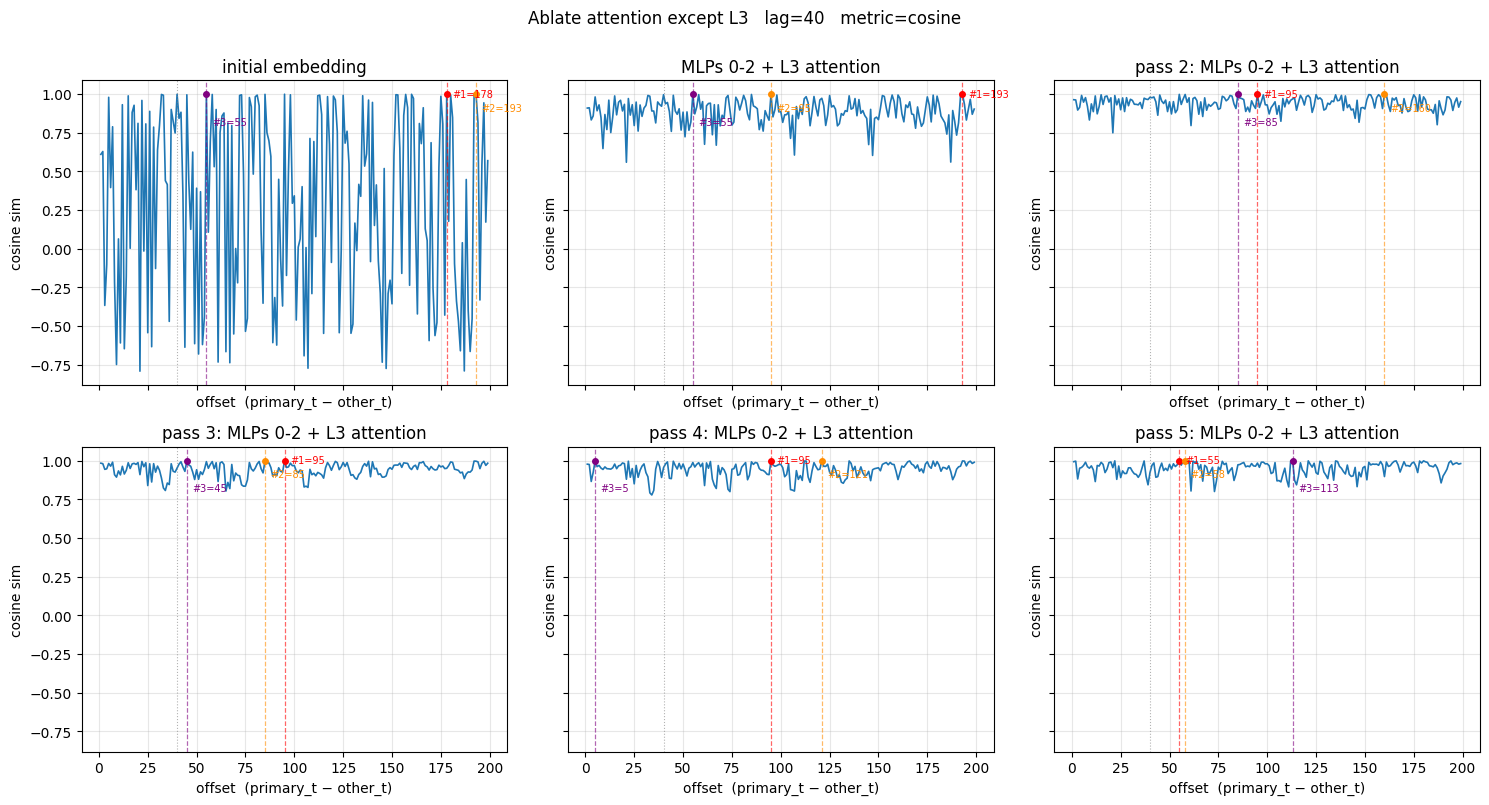

In [126]:
def apply_mlps_until_target_attn(model_used, resid, target_li=3, include_target_mlp=False):
    if not model_used.use_mlp:
        raise ValueError("this model doesn't have MLPs")

    B, T, _ = resid.shape

    pos = torch.arange(T, device=device).unsqueeze(0).expand(B, T)
    idx = torch.arange(T, device=device)
    mask = idx.unsqueeze(0) > idx.unsqueeze(1)

    x = resid

    for li, heads in enumerate(model_used.layers):
        if li < target_li:
            x = x + model_used.mlps[li](x)

        elif li == target_li:
            delta = torch.zeros_like(x)

            for head_params in heads:
                A, d = model_used._head(x, head_params, pos, mask)
                delta = delta + d

            x = x + delta

            if include_target_mlp:
                x = x + model_used.mlps[li](x)

            break

    return x

model_used = model
LAG = 40
primary_t = 199
t_lower   = 0
METRIC = "cosine"
N_TOP = 3
top_colors = ["red", "darkorange", "purple"]
num_passes = 5

seq = generate_autocorr(T=200, rho=0.9, lag=LAG, seed=0)
x = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(device)

model_used.eval()

with torch.no_grad():
    resid = model_used.W_r(x.unsqueeze(-1))

    snapshots = [resid.clone()]

    for pass_num in range(num_passes):
        resid = apply_mlps_until_target_attn(
            model_used,
            resid,
            target_li=3,
            include_target_mlp=False
        )
        snapshots.append(resid.clone())

n_plots = len(snapshots)
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows),
                         sharex=True, sharey=True, squeeze=False)
axes = axes.flatten()

for pass_num, resid in enumerate(snapshots):
    ax = axes[pass_num]

    sims_dict = similarity_by_offset(resid, primary_t, t_lower, metric=METRIC)
    plot_similarity_panel(ax, sims_dict, "tab:blue", LAG, N_TOP, top_colors)

    if pass_num == 0:
        ax.set_title("initial embedding")
    elif pass_num == 1:
        ax.set_title("MLPs 0-2 + L3 attention")
    else:
        ax.set_title(f"pass {pass_num}: MLPs 0-2 + L3 attention")

    ax.set_xlabel("offset  (primary_t − other_t)")
    ax.set_ylabel({"cosine": "cosine sim", "dot": "dot product"}[METRIC])
    ax.grid(alpha=0.3)

for ax in axes[n_plots:]:
    ax.axis("off")

fig.suptitle(f"Ablate attention except L3   lag={LAG}   metric={METRIC}", y=1.001)
fig.tight_layout()
plt.show()

using sequence 6


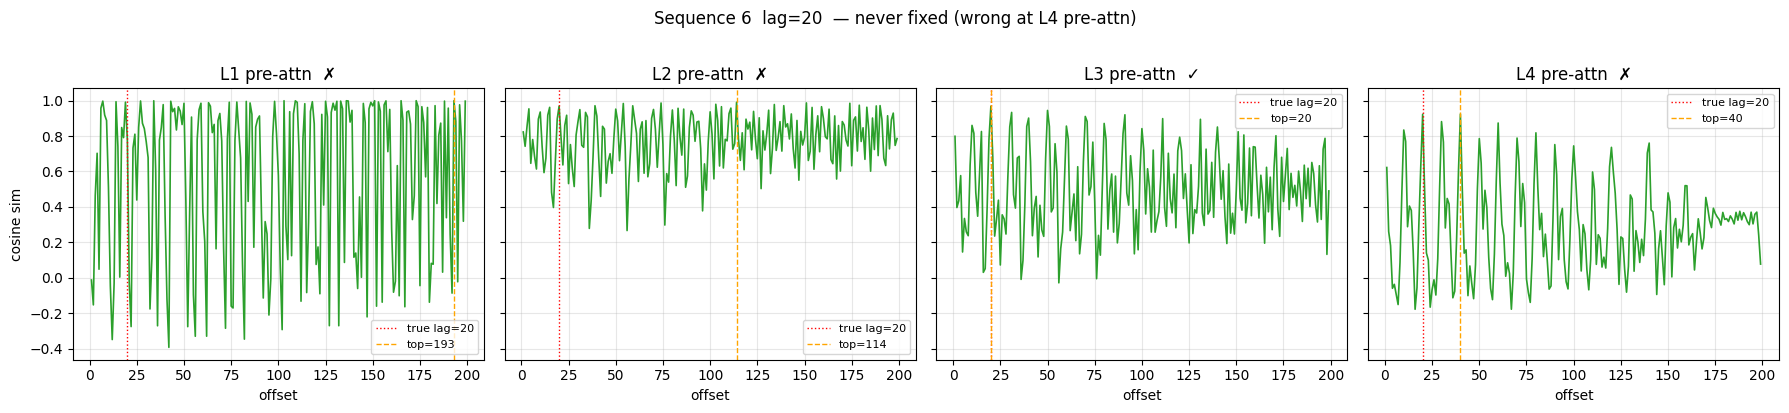

In [120]:
# find a sequence where L4 pre-attn is WRONG (representation never got fixed)
LAG = 20
xL, _, _ = make_dataset_lagset(N_SEQS, T, rho, [LAG], seed=LAG)
xL = xL.to(device)

with torch.no_grad():
    _, _, resids_post_attn, resids_post_mlp = model(xL)
    embedding = model.W_r(xL.unsqueeze(-1))

wrong_seq = None
for s in range(N_SEQS):
    # check L4 pre-attn = resids_post_mlp[2] (layer 3, 0-indexed)
    resid_l4_pre = resids_post_mlp[2]
    vec    = resid_l4_pre[s, primary_t, :]
    others = resid_l4_pre[s, :primary_t, :]
    sims   = F.cosine_similarity(vec.unsqueeze(0), others, dim=1)
    top    = int(primary_t - sims.argmax().item())
    if abs(top - LAG) > TOL:
        wrong_seq = s
        break

if wrong_seq is None:
    print("all sequences correct at L4 pre-attn — try a higher lag")
else:
    print(f"using sequence {wrong_seq}")

    fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

    for li in LAYERS:
        resid_pre = embedding if li == 0 else resids_post_mlp[li - 1]
        vec    = resid_pre[wrong_seq, primary_t, :]
        others = resid_pre[wrong_seq, :primary_t, :]
        sims   = F.cosine_similarity(vec.unsqueeze(0), others, dim=1).cpu().numpy()
        offsets = np.arange(1, primary_t + 1)

        top_offset = int(primary_t - np.argmax(sims))
        correct    = abs(top_offset - LAG) <= TOL

        ax = axes[li]
        ax.plot(offsets, sims[::-1], lw=1.2, color="tab:green")
        ax.axvline(LAG,        color="red",    ls=":",  lw=1, label=f"true lag={LAG}")
        ax.axvline(top_offset, color="orange", ls="--", lw=1, label=f"top={top_offset}")
        ax.set_title(f"L{li+1} pre-attn  {'✓' if correct else '✗'}")
        ax.set_xlabel("offset")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    axes[0].set_ylabel("cosine sim")
    fig.suptitle(f"Sequence {wrong_seq}  lag={LAG}  — never fixed (wrong at L4 pre-attn)",
                 y=1.02)
    fig.tight_layout()
    plt.show()

In [54]:
print(df['end_top1'].value_counts().head(5))
print(df['start_top1'].value_counts().head(5))

20     52
40      6
60      3
80      3
120     2
Name: end_top1, dtype: int64
20     3
75     3
159    3
17     2
150    2
Name: start_top1, dtype: int64


#### Observations about the figure
- ATTENTION layer 4 retrieves by similarity?
    - show mathematically later?

- First want to see whats going on with the periodic - ness
- Is rope causing this? 
- Does the same pattern result in the attention only model?

In [ ]:

from torch.optim import AdamW

T, rho = 200, 0.9
train_lags = list(range(1, 51))
held_high  = [52, 55, 58]
batch_size, num_steps = 64, 150000
lr, weight_decay, burn_in = 1e-3, 0.1, 30
eval_every = 10000

x_tr, _, lags_tr = make_dataset_lagset(3000, T, rho, train_lags, seed=1)
x_hi, _, lags_hi = make_dataset_lagset(3000, T, rho, held_high,  seed=3)
x_tr, lags_tr = x_tr.to(device), lags_tr.to(device)
x_hi, lags_hi = x_hi.to(device), lags_hi.to(device)

def masked_loss(pred, y, lags, burn_in):
    Tn  = pred.shape[1]
    pos = torch.arange(Tn, device=pred.device).unsqueeze(0)
    valid = pos >= (lags.unsqueeze(1) + burn_in)
    se    = (pred - y) ** 2
    return ((se * valid).sum(1) / valid.sum(1).clamp(min=1)).mean()

m = lambda d: float(np.mean(list(d.values())))

for n_lay in [2, 3, 5]:
    print(f"\n{'='*50}\nTRAINING {n_lay}-LAYER MODEL\n{'='*50}")
    mdl = AutocorrRoPE(d_model=64, d_head=64, n_layers=n_lay,
                       n_heads=1, use_mlp=True, act_function='GELU').to(device)
    opt = AdamW(mdl.parameters(), lr=lr, weight_decay=weight_decay)

    for step in range(1, num_steps + 1):
        x, y, lags = make_dataset_lagset(batch_size, T, rho, train_lags, seed=None)
        x, y, lags = x.to(device), y.to(device), lags.to(device)
        pred, *_ = mdl(x)
        loss = masked_loss(pred, y, lags, burn_in)
        opt.zero_grad(); loss.backward(); opt.step()
        if step % eval_every == 0:
            tr  = m(correlation_by_lag(mdl, x_tr, lags_tr, device, verbose=False))
            ext = m(correlation_by_lag(mdl, x_hi, lags_hi, device, verbose=False))
            print(f"  [{n_lay}L] step {step:6d}  loss {loss.item():.4f}  train {tr:.3f}  extrap {ext:.3f}")

    ckpt = f'sweep_d64_{n_lay}L_mlp.pt'
    torch.save(mdl.state_dict(), ckpt)
    tr  = m(correlation_by_lag(mdl, x_tr, lags_tr, device, verbose=False))
    ext = m(correlation_by_lag(mdl, x_hi, lags_hi, device, verbose=False))
    print(f"  saved -> {ckpt}   FINAL train {tr:.3f}  extrap {ext:.3f}")

print("\n=== all depth models trained ===")
print("compare to 4L: train 0.974  extrap 0.799")


TRAINING 2-LAYER MODEL
  [2L] step  10000  loss 0.8942  train 0.311  extrap 0.012
  [2L] step  20000  loss 0.9187  train 0.314  extrap 0.012
  [2L] step  30000  loss 0.9354  train 0.315  extrap 0.014
  [2L] step  40000  loss 0.8894  train 0.323  extrap 0.006
  [2L] step  50000  loss 0.9204  train 0.324  extrap 0.023
  [2L] step  60000  loss 0.8824  train 0.325  extrap 0.034
  [2L] step  70000  loss 0.9388  train 0.323  extrap 0.024
  [2L] step  80000  loss 0.9228  train 0.320  extrap 0.034
  [2L] step  90000  loss 0.9423  train 0.322  extrap 0.035
  [2L] step 100000  loss 0.9045  train 0.323  extrap 0.039
  [2L] step 110000  loss 0.8848  train 0.323  extrap 0.043
  [2L] step 120000  loss 0.9148  train 0.340  extrap 0.059
  [2L] step 130000  loss 0.8807  train 0.338  extrap 0.063
  [2L] step 140000  loss 0.8506  train 0.337  extrap 0.065
  [2L] step 150000  loss 0.9092  train 0.329  extrap 0.081
  saved -> sweep_d64_2L_mlp.pt   FINAL train 0.329  extrap 0.081

TRAINING 3-LAYER MODEL
  